<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/dexpi_safety_study_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEXPI 2.0 to safety-study workflow with NeqSim

This notebook creates a calculated gas-processing model, exports a DEXPI 2.0
P&ID data file, inspects its semantic content, and turns the result into a
traceable safety-study preparation pack.

The example is an educational data-quality workflow. It is not an approved P&ID,
HAZOP, SIL assessment, relief design, or operating procedure. Project teams must
validate identifiers, connectivity, units, design limits, safety functions, and
document revisions against controlled engineering sources.

## Learning objectives

After completing the notebook, you can:

1. distinguish a DEXPI exchange model from a completed safety study;
2. export a native NeqSim `ProcessSystem` using the DEXPI 2.0 writer;
3. inspect equipment, piping, instrumentation, and design-condition semantics;
4. form HAZOP nodes and cause-and-effect records from verified model objects;
5. calculate completeness and traceability indicators;
6. identify safety metadata that requires a project-side study register.

## Standards boundary

- **DEXPI 2.0** defines exchange models for process and plant information; its
  P&ID specification is an implementation of the broader IEC 62424 exchange
  approach.
- **IEC 62424:2016** covers representation of process-control engineering
  requests in P&IDs and exchange between engineering tools.
- **IEC 61882:2016** governs HAZOP preparation, examination, documentation,
  and follow-up.
- **IEC 61511:2016** governs the safety lifecycle when risk reduction is
  allocated to a safety instrumented function.

A syntactically valid DEXPI file can support a study, but it does not prove that
safeguards are independent, that SIL targets are correct, or that study actions
are closed.

## Data-quality model

Treat the exchange file as a semantic graph $G=(V,E)$, where $V$ contains
equipment, streams, instruments, and safety functions, while $E$ contains
process and signal connectivity.

For a study object with $n_{\mathrm{required}}$ required attributes and
$n_{\mathrm{verified}}$ verified attributes, define:

$$
C = \frac{n_{\mathrm{verified}}}{n_{\mathrm{required}}}
$$

`Present` is weaker than `verified`: a tag may exist while its safety role,
voting, trip set point, proof-test interval, or safe state remains absent.

In [1]:
%pip install -q "neqsim==3.16.0" "pandas>=2.2" "matplotlib>=3.8"

## Imports and runtime evidence

In [2]:
import hashlib
import importlib.metadata
import json
import platform
import sys
from pathlib import Path
from xml.etree import ElementTree as ET

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))

,version
neqsim,3.16.0
python,3.12.13
java,17.0.19
numpy,2.5.1
pandas,3.0.5
matplotlib,3.11.1


## Design basis

The synthetic case represents a 90 bara rich-gas feed protected by a 2oo3
pressure-sensing HIPPS. Two downstream pressure levels and a 100 bara separator
design pressure create a useful traceability case.

In [3]:
design_basis = pd.DataFrame(
    [
        ["Feed flow", 60_000.0, "kg/h", "Normal operation"],
        ["Feed pressure", 90.0, "bara", "Upstream source"],
        ["Separator pressure", 75.0, "bara", "Protected system"],
        ["Separator design pressure", 100.0, "bara", "Illustrative"],
        ["Relief set pressure", 95.0, "bara", "Illustrative"],
        ["HIPPS trip set point", 82.0, "bara", "Study register"],
        ["HIPPS voting", "2oo3", "-", "Study register"],
        ["HIPPS closure time", 6.0, "s", "Study register"],
    ],
    columns=["Parameter", "Value", "Unit", "Data owner"],
)
display(design_basis)

,Parameter,Value,Unit,Data owner
0,Feed flow,60000.0,kg/h,Normal operation
1,Feed pressure,90.0,bara,Upstream source
2,Separator pressure,75.0,bara,Protected system
3,Separator design pressure,100.0,bara,Illustrative
4,Relief set pressure,95.0,bara,Illustrative
5,HIPPS trip set point,82.0,bara,Study register
6,HIPPS voting,2oo3,-,Study register
7,HIPPS closure time,6.0,s,Study register


## Build and run the native process model

In [4]:
components = [
    ("nitrogen", 0.010),
    ("CO2", 0.020),
    ("methane", 0.860),
    ("ethane", 0.070),
    ("propane", 0.040),
]

fluid = ns.thermo.system.SystemSrkEos(308.15, 90.0)
for component, mole_fraction in components:
    fluid.addComponent(component, mole_fraction)
fluid.createDatabase(True)
fluid.setMixingRule(2)
fluid.setMultiPhaseCheck(True)

feed = ns.process.equipment.stream.Stream("Feed-101", fluid)
feed.setFlowRate(60_000.0, "kg/hr")

hipps = ns.process.equipment.valve.HIPPSValve("HIPPS-XV-101", feed)
hipps.setOutletPressure(75.0, "bara")
hipps.setClosureTime(6.0)
hipps.setSILRating(3)
hipps.setProofTestInterval(8760.0)
hipps.setVotingLogic(
    ns.process.equipment.valve.HIPPSValve.VotingLogic.TWO_OUT_OF_THREE
)

separator = ns.process.equipment.separator.Separator(
    "V-101 HP Separator",
    hipps.getOutletStream(),
)
compressor = ns.process.equipment.compressor.Compressor(
    "K-101 Export Compressor",
    separator.getGasOutStream(),
)
compressor.setOutletPressure(105.0, "bara")
compressor.setIsentropicEfficiency(0.75)

aftercooler = ns.process.equipment.heatexchanger.Cooler(
    "E-101 Export Aftercooler",
    compressor.getOutletStream(),
)
aftercooler.setOutTemperature(313.15)

design = ns.process.mechanicaldesign.DesignConditions()
design.setDesignPressure(100.0)
design.setMaxDesignTemperature(120.0)
design.setMinDesignTemperature(-29.0)
design.setReliefSetPressure(95.0)
design.setConstructionMaterial("Carbon steel - illustrative")
separator.setDesignConditions(design)

transmitters = []
for suffix in ["A", "B", "C"]:
    tag = f"PSHH-101{suffix}"
    transmitter = ns.process.measurementdevice.PressureTransmitter(tag, feed)
    transmitter.setTagName(tag)
    transmitter.setUnit("bara")
    transmitter.setMinimumValue(0.0)
    transmitter.setMaximumValue(120.0)
    hipps.addPressureTransmitter(transmitter)
    transmitters.append(transmitter)

process = ns.process.processmodel.ProcessSystem()
for unit in [
    feed,
    hipps,
    separator,
    compressor,
    aftercooler,
    *transmitters,
]:
    process.add(unit)
process.run()

In [5]:
mass_in = float(feed.getFlowRate("kg/hr"))
mass_out = float(
    separator.getGasOutStream().getFlowRate("kg/hr")
    + separator.getLiquidOutStream().getFlowRate("kg/hr")
)
process_results = pd.DataFrame(
    [
        ["Feed pressure", feed.getPressure("bara"), "bara"],
        ["HIPPS outlet pressure", hipps.getOutletPressure(), "bara"],
        [
            "Separator gas temperature",
            separator.getGasOutStream().getTemperature("C"),
            "°C",
        ],
        [
            "Compressor discharge pressure",
            compressor.getOutletPressure(),
            "bara",
        ],
        [
            "Aftercooler outlet temperature",
            aftercooler.getOutletStream().getTemperature("C"),
            "°C",
        ],
        ["Mass-balance relative error", abs(mass_in - mass_out) / mass_in, "-"],
    ],
    columns=["Result", "Value", "Unit"],
)
display(process_results)

,Result,Value,Unit
0,Feed pressure,90.000000,bara
1,HIPPS outlet pressure,75.000000,bara
2,Separator gas temperature,28.943467,°C
3,Compressor discharge pressure,105.000000,bara
4,Aftercooler outlet temperature,40.000000,°C
5,Mass-balance relative error,0.000000,-


## Calculated process with safety-study overlay

Blue objects are process equipment. Orange objects are safety-study records that
must retain traceable links even when an exchange schema does not carry all their
lifecycle attributes.

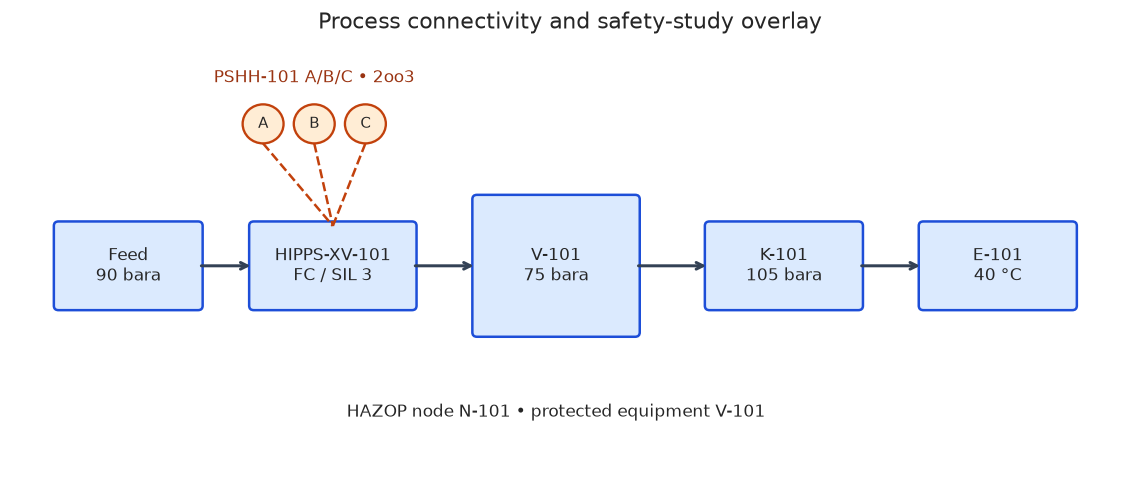

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

equipment = [
    (0.5, 2.1, 1.5, 0.9, "Feed\n90 bara"),
    (2.6, 2.1, 1.7, 0.9, "HIPPS-XV-101\nFC / SIL 3"),
    (5.0, 1.8, 1.7, 1.5, "V-101\n75 bara"),
    (7.5, 2.1, 1.6, 0.9, "K-101\n105 bara"),
    (9.8, 2.1, 1.6, 0.9, "E-101\n40 °C"),
]
for x, y, width, height, label in equipment:
    box = patches.FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor="#dbeafe",
        edgecolor="#1d4ed8",
        linewidth=1.5,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center")

for x0, x1 in [(2.0, 2.6), (4.3, 5.0), (6.7, 7.5), (9.1, 9.8)]:
    ax.annotate(
        "",
        xy=(x1, 2.55),
        xytext=(x0, 2.55),
        arrowprops={"arrowstyle": "->", "color": "#334155", "lw": 1.8},
    )

for index, suffix in enumerate(["A", "B", "C"]):
    x = 2.7 + index * 0.55
    sensor = patches.Circle(
        (x, 4.15),
        0.22,
        facecolor="#ffedd5",
        edgecolor="#c2410c",
        linewidth=1.4,
    )
    ax.add_patch(sensor)
    ax.text(x, 4.15, suffix, ha="center", va="center", fontsize=9)
    ax.plot([x, 3.45], [3.93, 3.0], color="#c2410c", linestyle="--")
ax.text(3.25, 4.62, "PSHH-101 A/B/C • 2oo3", ha="center", color="#9a3412")
ax.text(5.85, 0.85, "HAZOP node N-101 • protected equipment V-101", ha="center")
ax.set_title("Process connectivity and safety-study overlay", pad=12)
plt.show()

## Export DEXPI 2.0

NeqSim writes the calculated `ProcessSystem` to DEXPI XML. The export is saved
only as a temporary notebook artifact; the digest makes the exact payload
identifiable during this run.

In [7]:
export_path = Path("dexpi_safety_study_workflow.xml")
java_file = jpype.JClass("java.io.File")(str(export_path.absolute()))
writer = ns.process.processmodel.dexpi.DexpiXmlWriter
writer.writeDexpi20(process, java_file)

payload = export_path.read_bytes()
root = ET.fromstring(payload)
plant_information = next(
    element
    for element in root.iter()
    if element.tag.split("}")[-1] == "PlantInformation"
)
schema_location_key = (
    "{http://www.w3.org/2001/XMLSchema-instance}schemaLocation"
)
export_evidence = pd.DataFrame(
    [
        ["File", export_path.name],
        ["Bytes", len(payload)],
        ["SHA-256", hashlib.sha256(payload).hexdigest()],
        ["Root tag", root.tag],
        [
            "SchemaVersion",
            plant_information.attrib.get("SchemaVersion", ""),
        ],
        ["Schema location", root.attrib.get(schema_location_key, "")],
    ],
    columns=["Evidence", "Value"],
)
display(export_evidence)

,Evidence,Value
0,File,dexpi_safety_study_workflow.xml
1,Bytes,136175
2,SHA-256,73098099f06f0c492b2798a85a2529a66c62a3299bf85f6359e07658d160f5ac
3,Root tag,{http://www.dexpi.org/dexpi}PlantModel
4,SchemaVersion,2.0
5,Schema location,http://www.dexpi.org/dexpi http://www.dexpi.org/dexpi/DEXPI-2.0.xsd


## Semantic inventory and connectivity checks

In [8]:
def local_name(element):
    return element.tag.split("}")[-1]


elements = list(root.iter())
local_names = pd.Series([local_name(element) for element in elements])
inventory_names = [
    "Equipment",
    "PipingNetworkSegment",
    "PipingNetworkSystem",
    "ProcessInstrumentationFunction",
    "InstrumentationLoopFunction",
    "Nozzle",
]
inventory = pd.DataFrame(
    {
        "DEXPI object": inventory_names,
        "Count": [
            sum(
                local_name(element) == name
                and bool(element.attrib.get("ComponentClass"))
                for element in elements
            )
            for name in inventory_names
        ],
    }
)
display(inventory)

tagged_elements = []
for element in elements:
    element_type = local_name(element)
    tag = element.attrib.get("ID", "")
    if element_type in [
        "Equipment",
        "PipingComponent",
        "ProcessInstrumentationFunction",
    ]:
        tagged_elements.append(
            {
                "Element": element_type,
                "Tag": tag,
                "Class": element.attrib.get("ComponentClass", ""),
            }
        )
tagged_frame = pd.DataFrame(tagged_elements)
mask = tagged_frame["Tag"].str.contains(
    "V-101|K-101|E-101|HIPPS|PSHH",
    regex=True,
    na=False,
)
display(tagged_frame.loc[mask].drop_duplicates().reset_index(drop=True))

,DEXPI object,Count
0,Equipment,3
1,PipingNetworkSegment,4
2,PipingNetworkSystem,1
3,ProcessInstrumentationFunction,3
4,InstrumentationLoopFunction,3
5,Nozzle,9


,Element,Tag,Class
0,Equipment,V-101-HP-Separator,Separator
1,Equipment,K-101-Export-Compressor,CentrifugalCompressor
2,Equipment,E-101-Export-Aftercooler,AirCoolingSystem
3,PipingComponent,HIPPS-XV-101,GlobeValve
4,ProcessInstrumentationFunction,PSHH-101A,ProcessInstrumentationFunction
5,ProcessInstrumentationFunction,PSHH-101B,ProcessInstrumentationFunction
6,ProcessInstrumentationFunction,PSHH-101C,ProcessInstrumentationFunction


## Safety semantics audit

The audit separates:

- **exchange evidence** found in the XML;
- **study-register evidence** held by the safety study;
- **verified mapping** where the two agree.

This is intentionally stricter than checking whether a tag string appears.

In [9]:
xml_text = payload.decode("utf-8")
audit_rows = [
    [
        "V-101 design pressure",
        "100 bara",
        "DesignPressure" in xml_text and "100" in xml_text,
        "Mechanical design basis",
    ],
    [
        "V-101 minimum design temperature",
        "-29 °C",
        "MinimumDesignTemperature" in xml_text
        or "MinDesignTemperature" in xml_text,
        "Mechanical design basis",
    ],
    [
        "HIPPS valve tag",
        "HIPPS-XV-101",
        "HIPPS-XV-101" in xml_text,
        "P&ID / SRS",
    ],
    [
        "Pressure sensor tags",
        "PSHH-101A/B/C",
        all(f"PSHH-101{x}" in xml_text for x in "ABC"),
        "P&ID / SRS",
    ],
    [
        "SIL target",
        "SIL 3",
        "SIL3" in xml_text or "SIL 3" in xml_text,
        "LOPA / SRS",
    ],
    [
        "Voting",
        "2oo3",
        "2oo3" in xml_text,
        "SRS",
    ],
    [
        "Trip set point",
        "82 bara",
        "82" in xml_text and "Trip" in xml_text,
        "SRS / C&E",
    ],
    [
        "Proof-test interval",
        "8760 h",
        "8760" in xml_text and "Proof" in xml_text,
        "SRS / maintenance",
    ],
    [
        "Safe state",
        "Fail closed",
        "FailPosition" in xml_text and "FC" in xml_text,
        "P&ID / C&E",
    ],
]
semantics_audit = pd.DataFrame(
    audit_rows,
    columns=["Required semantic", "Expected", "Found in XML", "Authority"],
)
semantics_audit["Status"] = np.where(
    semantics_audit["Found in XML"],
    "Present - verify",
    "Gap - retain in study register",
)
display(semantics_audit)

,Required semantic,Expected,Found in XML,Authority,Status
0,V-101 design pressure,100 bara,True,Mechanical design basis,Present - verify
1,V-101 minimum design temperature,-29 °C,True,Mechanical design basis,Present - verify
2,HIPPS valve tag,HIPPS-XV-101,True,P&ID / SRS,Present - verify
3,Pressure sensor tags,PSHH-101A/B/C,True,P&ID / SRS,Present - verify
4,SIL target,SIL 3,False,LOPA / SRS,Gap - retain in study register
5,Voting,2oo3,False,SRS,Gap - retain in study register
6,Trip set point,82 bara,False,SRS / C&E,Gap - retain in study register
7,Proof-test interval,8760 h,False,SRS / maintenance,Gap - retain in study register
8,Safe state,Fail closed,True,P&ID / C&E,Present - verify


## Semantic graph view

The graph below is a study-oriented projection, not a full P&ID renderer. It
exposes the relationships needed to ask whether every hazardous node, safety
function, final element, and protected item has a stable identifier.

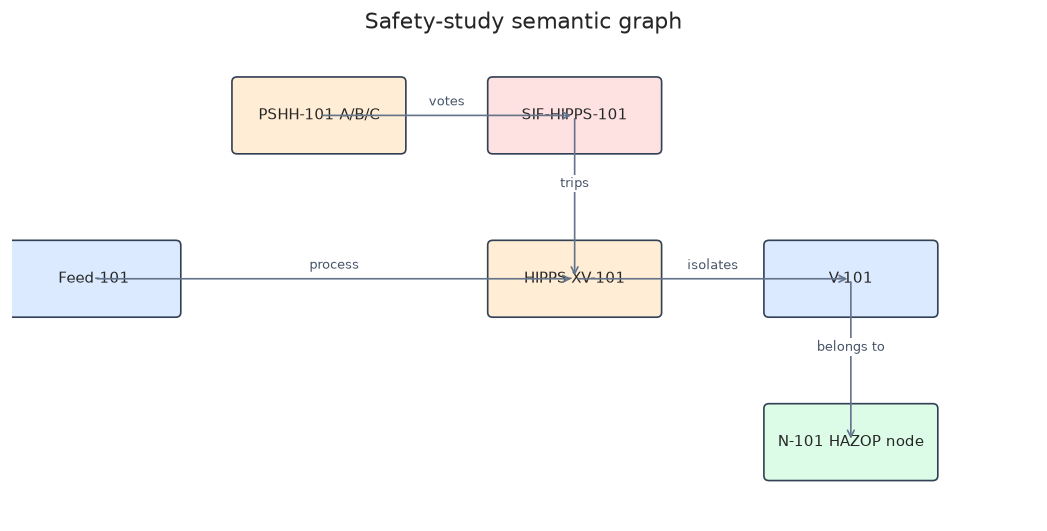

In [10]:
nodes = {
    "Feed-101": (0.8, 2.5, "#dbeafe"),
    "PSHH-101 A/B/C": (3.0, 4.2, "#ffedd5"),
    "SIF-HIPPS-101": (5.5, 4.2, "#fee2e2"),
    "HIPPS-XV-101": (5.5, 2.5, "#ffedd5"),
    "V-101": (8.2, 2.5, "#dbeafe"),
    "N-101 HAZOP node": (8.2, 0.8, "#dcfce7"),
}
edges = [
    ("Feed-101", "HIPPS-XV-101", "process"),
    ("PSHH-101 A/B/C", "SIF-HIPPS-101", "votes"),
    ("SIF-HIPPS-101", "HIPPS-XV-101", "trips"),
    ("HIPPS-XV-101", "V-101", "isolates"),
    ("V-101", "N-101 HAZOP node", "belongs to"),
]
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")
for label, (x, y, color) in nodes.items():
    box = patches.FancyBboxPatch(
        (x - 0.8, y - 0.35),
        1.6,
        0.7,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor="#334155",
    )
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center", fontsize=9)
for source, target, relation in edges:
    x0, y0, _ = nodes[source]
    x1, y1, _ = nodes[target]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops={"arrowstyle": "->", "color": "#64748b"},
    )
    ax.text(
        (x0 + x1) / 2,
        (y0 + y1) / 2 + 0.14,
        relation,
        ha="center",
        va="center",
        fontsize=8,
        color="#475569",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
    )
ax.set_title("Safety-study semantic graph")
plt.show()

## HAZOP node and design-intent register

In [11]:
hazop_nodes = pd.DataFrame(
    [
        [
            "N-100",
            "Feed and HIPPS isolation",
            "Limit inflow and isolate on high-high pressure",
            "Feed-101; HIPPS-XV-101",
            "No/More/Less/Reverse flow; More pressure",
        ],
        [
            "N-101",
            "HP separation",
            "Separate at 75 bara within 100 bara design pressure",
            "V-101",
            "More pressure; High/Low level; Other composition",
        ],
        [
            "N-102",
            "Compression and cooling",
            "Export at 105 bara and 40 °C",
            "K-101; E-101",
            "No flow; More pressure; High temperature",
        ],
    ],
    columns=[
        "Node",
        "Scope",
        "Design intent",
        "DEXPI tags",
        "Guide-word prompts",
    ],
)
display(hazop_nodes)

,Node,Scope,Design intent,DEXPI tags,Guide-word prompts
0,N-100,Feed and HIPPS isolation,Limit inflow and isolate on high-high pressure,Feed-101; HIPPS-XV-101,No/More/Less/Reverse flow; More pressure
1,N-101,HP separation,Separate at 75 bara within 100 bara design pressure,V-101,More pressure; High/Low level; Other composition
2,N-102,Compression and cooling,Export at 105 bara and 40 °C,K-101; E-101,No flow; More pressure; High temperature


## Cause-and-effect and safety-function register

In [12]:
cause_effect = pd.DataFrame(
    [
        [
            "PSHH-101A/B/C",
            "2oo3 pressure ≥ 82 bara",
            "SIF-HIPPS-101",
            "Close HIPPS-XV-101",
            "V-101",
            "SIL 3",
        ],
        [
            "ESD-101",
            "Manual ESD or confirmed F&G",
            "ESD-101",
            "Stop K-101; isolate feed",
            "Compression module",
            "Project allocation",
        ],
        [
            "BD-101",
            "ESD confirmed and permissives met",
            "BD-SIF-101",
            "Open blowdown valve",
            "V-101",
            "Project allocation",
        ],
    ],
    columns=[
        "Initiator tag",
        "Trip condition",
        "Function",
        "Final action",
        "Protected item",
        "Integrity target",
    ],
)
display(cause_effect)

,Initiator tag,Trip condition,Function,Final action,Protected item,Integrity target
0,PSHH-101A/B/C,2oo3 pressure ≥ 82 bara,SIF-HIPPS-101,Close HIPPS-XV-101,V-101,SIL 3
1,ESD-101,Manual ESD or confirmed F&G,ESD-101,Stop K-101; isolate feed,Compression module,Project allocation
2,BD-101,ESD confirmed and permissives met,BD-SIF-101,Open blowdown valve,V-101,Project allocation


## Cross-study readiness matrix

Green means the attribute is present in the combined DEXPI-plus-register package.
Orange means a named study owner must verify or supply it. The matrix prevents
one document from being treated as the sole source for every discipline.

,Connectivity,Design pressure,Trip set point,Voting,Proof-test interval,Response time,Safe state,Action close-out,Coverage
HAZOP,1,1,1,0,0,0,1,1,62%
SIL/LOPA,1,1,1,1,1,0,1,0,75%
ESD,1,1,1,1,1,1,1,0,88%
HIPPS,1,1,1,1,1,1,1,0,88%
Depressurization,1,1,0,0,0,1,1,0,50%


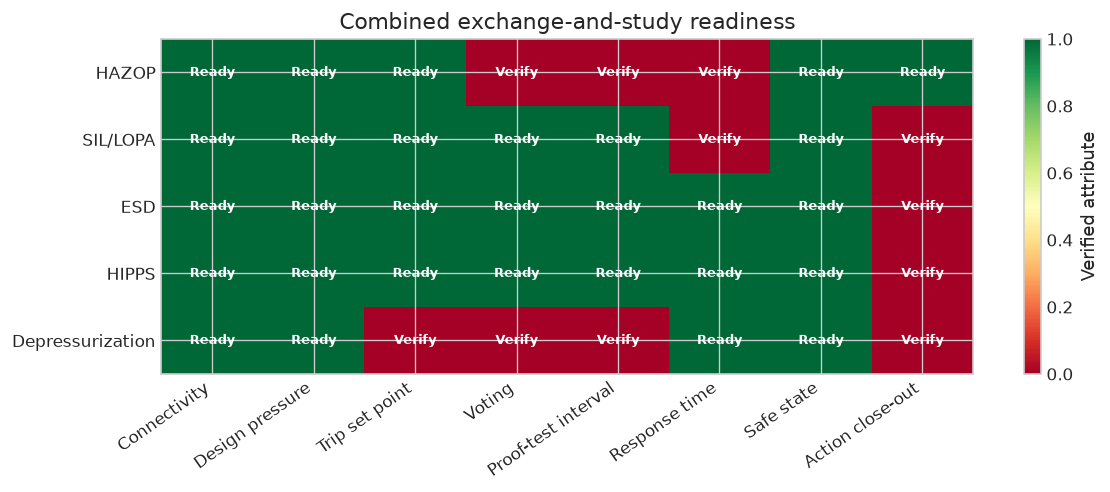

In [13]:
readiness = pd.DataFrame(
    {
        "Connectivity": [1, 1, 1, 1, 1],
        "Design pressure": [1, 1, 1, 1, 1],
        "Trip set point": [1, 1, 1, 1, 0],
        "Voting": [0, 1, 1, 1, 0],
        "Proof-test interval": [0, 1, 1, 1, 0],
        "Response time": [0, 0, 1, 1, 1],
        "Safe state": [1, 1, 1, 1, 1],
        "Action close-out": [1, 0, 0, 0, 0],
    },
    index=["HAZOP", "SIL/LOPA", "ESD", "HIPPS", "Depressurization"],
)
readiness["Coverage"] = readiness.mean(axis=1)
display(readiness.style.format({"Coverage": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(10, 4.2))
matrix = readiness.drop(columns="Coverage")
image = ax.imshow(matrix.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=35, ha="right")
ax.set_yticks(range(len(matrix.index)), matrix.index)
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        label = "Ready" if matrix.iloc[row, column] else "Verify"
        ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )
ax.set_title("Combined exchange-and-study readiness")
fig.colorbar(image, ax=ax, label="Verified attribute")
plt.tight_layout()
plt.show()

## Known DEXPI safety-semantic gap

In NeqSim 3.16.0, the export preserves the HIPPS valve tag and fail position, but
the specialized `HIPPSValve` is serialized as a generic globe valve. The three
high-high pressure transmitters are serialized with DCS control-system semantics;
their 2oo3 voting, SIL 3 claim, proof-test interval, and trip set point are not
preserved as a coherent safety function.

The reproducible enhancement request is tracked in
[NeqSim issue #2653](https://github.com/equinor/neqsim/issues/2653).
Until the exporter carries these fields, retain a controlled SIF/C&E register and
join it by stable identifiers.

## Validation checks

In [14]:
checks = {
    "mass_balance_relative_error_below_1e-6": (
        abs(mass_in - mass_out) / mass_in < 1.0e-6
    ),
    "dexpi_2_schema_declared": (
        plant_information.attrib.get("SchemaVersion") == "2.0"
    ),
    "protected_equipment_tag_present": "V-101" in xml_text,
    "hipps_valve_tag_present": "HIPPS-XV-101" in xml_text,
    "three_pressure_sensor_tags_present": all(
        f"PSHH-101{x}" in xml_text for x in "ABC"
    ),
    "hazop_nodes_have_unique_ids": hazop_nodes["Node"].is_unique,
    "cause_effect_functions_have_ids": cause_effect["Function"].notna().all(),
    "semantic_gap_detected": not semantics_audit.loc[
        semantics_audit["Required semantic"] == "Voting",
        "Found in XML",
    ].item(),
}
validation = pd.DataFrame(
    [{"Check": key, "Pass": bool(value)} for key, value in checks.items()]
)
display(validation)
assert validation["Pass"].all(), validation

,Check,Pass
0,mass_balance_relative_error_below_1e-6,True
1,dexpi_2_schema_declared,True
2,protected_equipment_tag_present,True
3,hipps_valve_tag_present,True
4,three_pressure_sensor_tags_present,True
5,hazop_nodes_have_unique_ids,True
6,cause_effect_functions_have_ids,True
7,semantic_gap_detected,True


## What to do next

1. Replace synthetic tags and limits with the controlled project design basis.
2. Validate the DEXPI file against the applicable schema and the receiving tool.
3. Reconcile the semantic graph with line lists, instrument indexes, C&E, SRS,
   relief registers, and the HAZOP action log.
4. Add document revision, source, owner, verification status, and change history
   to every imported attribute.
5. Re-run traceability checks after each P&ID or safety-study revision.

Useful exercises are to add a PSV, distinguish process-control and SIS sensors,
model a bypass with administrative controls, and calculate delta reports between
two DEXPI revisions.

## References

- [DEXPI specifications](https://dexpi.org/specifications/)
- [DEXPI 2.0 publication](https://dexpi.org/dexpi-2-0-specification-published-a-new-standard-for-process-industry-data-exchange/)
- [IEC 62424:2016](https://webstore.iec.ch/en/publication/25442)
- [IEC 61882:2016](https://webstore.iec.ch/en/publication/24321)
- [IEC 61511-1:2016](https://webstore.iec.ch/en/publication/24241)
- [NeqSim issue #2653](https://github.com/equinor/neqsim/issues/2653)